<a href="https://colab.research.google.com/github/dohaalnabahin/Data_science_and_machine_learning_Journey/blob/main/Stationarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import  statsmodels.tsa.api as tsa # new import
from sklearn import set_config
#set_config(transform_output="pandas")
plt.rcParams["figure.figsize"] = (12, 4)
sns.set_context("talk", font_scale=0.9)
# set random seed
SEED = 321
np.random.seed(SEED)

In [2]:
# Calculating a simulated white noise time series (one value)
c = 49
noise_t = np.random.normal()
# Add the random value to the mean to get the duration of the lap for one day
y_t= c + noise_t
y_t

49.17251946894025

In [3]:
# Calculating a simulated white noise time series for 120 days
c = 49
n_lags = 120
y = []
for t in range(n_lags):

    noise_t = np.random.normal(size=1)
    y_t = c + noise_t[0] # slicing 0 to get value instead of arrays
    y.append(y_t)

In [4]:
# Convet list to a Pandas Series
ts_white_noise = pd.Series(y, name='Simulated White Noise')
ts_white_noise

,Simulated White Noise
0,50.635483
1,49.037336
2,48.115850
3,47.856808
4,48.378634
...,...
115,50.081623
116,49.227369
117,50.421600
118,48.683405


#Plotting the White Noise Time Series

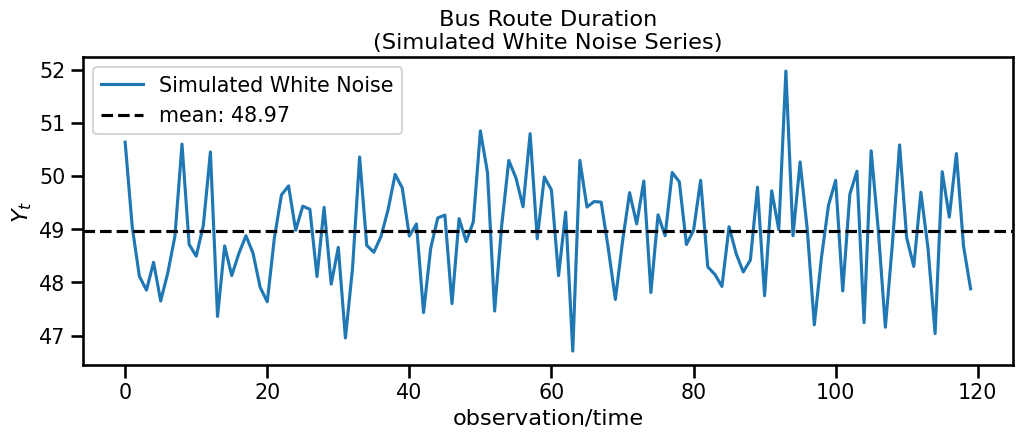

In [6]:
# Plotting the white noise series with annotated mean
ax = ts_white_noise.plot()
ax.set(title='Bus Route Duration\n(Simulated White Noise Series)',
       ylabel='$Y_t$', xlabel='observation/time');
ax.axhline( ts_white_noise.mean(),  color='k', ls='--',
           label=f'mean: {ts_white_noise.mean():.2f}');
ax.legend();

In [7]:
# Running the adfuller test to demonstrate return
tsa.adfuller(ts_white_noise)

(np.float64(-11.133859534698887),
 np.float64(3.2317307055655433e-20),
 0,
 119,
 {'1%': np.float64(-3.4865346059036564),
  '5%': np.float64(-2.8861509858476264),
  '10%': np.float64(-2.579896092790057)},
 np.float64(295.21163114049114))

In [8]:
# Saving each output separately
(test_stat, pval, nlags, nobs, crit_vals_d, icbest) = tsa.adfuller(ts_white_noise)

In [9]:
# Saving the most important results as a dictionary
adfuller_results = {'Test Statistic': test_stat,
                    "# of Lags Used":nlags,
                   '# of Observations':nobs,
                    'p-value': round(pval,6)}

In [10]:
# Adding interpretation of p-value to dictionary
alpha =.05
adfuller_results['sig/stationary?'] = pval < alpha
adfuller_results

{'Test Statistic': np.float64(-11.133859534698887),
 '# of Lags Used': 0,
 '# of Observations': 119,
 'p-value': np.float64(0.0),
 'sig/stationary?': np.True_}

In [11]:
# Convert dictionary of results to a dataframe
adfuller_df = pd.DataFrame(adfuller_results, index=['AD Fuller Test'])
adfuller_df

,Test Statistic,# of Lags Used,# of Observations,p-value,sig/stationary?
AD Fuller Test,-11.13386,0,119,0.0,True


In [12]:
# Custom function for Ad Fuller Test
def get_adfuller_results(ts, alpha=.05, label='adfuller', **kwargs): #kwargs for adfuller()
    # Saving each output
    (test_stat, pval, nlags, nobs, crit_vals_d,
    icbest ) = tsa.adfuller(ts, **kwargs)
    # Converting output to a dictionary with the interpretation of p
    adfuller_results = {'Test Statistic': test_stat,
                        "# of Lags Used":nlags,
                       '# of Observations':nobs,
                        'p-value': round(pval,6),
                        'alpha': alpha,
                       'sig/stationary?': pval < alpha}
    return pd.DataFrame(adfuller_results, index =[label])

In [13]:
# Testing the function
adfuller_results = get_adfuller_results(ts_white_noise, label='White Noise')
adfuller_results

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
White Noise,-11.13386,0,119,0.0,0.05,True
